In [115]:
import pandas as pd
import yfinance as yf

import numpy as np

import matplotlib.pyplot as plt


In [2]:
copper_data =pd.read_csv('copper_data.csv')

In [3]:
copper_data = copper_data[['Close', 'Close.2', 'Close.3', 'Close.4']]

In [4]:
cane_data = pd.read_csv('tradind_cane.csv')

In [ ]:
tickers = ["SBN26.NYB",'SBH27.NYB','SBV26.NYB','CANE' ]

data = yf.download(
    tickers,
    start="2025-01-01",
    end="2026-03-31",
    auto_adjust=True,
    group_by="ticker"
)

In [6]:
tickers = ["SBN26.NYB",'SBH27.NYB','SBV26.NYB','CANE' ]

data = yf.download(
    tickers,
    start="2025-01-01",
    end="2026-03-31",
    auto_adjust=True,
    group_by="ticker"
)

[*********************100%***********************]  4 of 4 completed


In [13]:
close_columns = [col for col in cane_data.columns if 'Close' in col]
cane_data = cane_data[close_columns]

In [7]:
cane_data = data

In [8]:
Close_price = cane_data.filter(like="Close")

# Usuń wiersze z NA
Close_price = Close_price.dropna()

MultiIndex([('SBH27.NYB',   'Open'),
            ('SBH27.NYB',   'High'),
            ('SBH27.NYB',    'Low'),
            ('SBH27.NYB',  'Close'),
            ('SBH27.NYB', 'Volume'),
            ('SBV26.NYB',   'Open'),
            ('SBV26.NYB',   'High'),
            ('SBV26.NYB',    'Low'),
            ('SBV26.NYB',  'Close'),
            ('SBV26.NYB', 'Volume'),
            ('SBN26.NYB',   'Open'),
            ('SBN26.NYB',   'High'),
            ('SBN26.NYB',    'Low'),
            ('SBN26.NYB',  'Close'),
            ('SBN26.NYB', 'Volume'),
            (     'CANE',   'Open'),
            (     'CANE',   'High'),
            (     'CANE',    'Low'),
            (     'CANE',  'Close'),
            (     'CANE', 'Volume')],
           names=['Ticker', 'Price'])

In [9]:
Close_price

Ticker,CANE,SBN26.NYB,SBH27.NYB,SBV26.NYB
Price,Close,Close,Close,Close
Date,,,,
2025-01-02,11.67,16.830000,17.070000,16.790001
2025-01-03,11.65,16.870001,17.139999,16.850000
2025-01-06,11.50,16.840000,17.150000,16.840000
2025-01-07,11.58,16.850000,17.150000,16.840000
2025-01-08,11.48,16.809999,17.120001,16.809999
...,...,...,...,...
2026-03-24,10.66,16.010000,16.940001,16.340000
2026-03-25,10.46,15.720000,16.730000,16.090000


In [10]:
ratio_h7 = 1275/6525000*1120
ratio_n6 = 1357/6525000*1120
ratio_v6 = 1136/6525000*1120

0.2188505747126437

In [11]:
Close_price['Spread']= Close_price['CANE']- ratio_h7*Close_price['SBH27.NYB']-ratio_n6*Close_price['SBN26.NYB']-ratio_v6*Close_price['SBV26.NYB']

In [43]:
Close_pr

Ticker,SBH27.NYB,SBV26.NYB,SBN26.NYB,CANE,Spread
Price,Close,Close,Close,Close,
Date,,,,,
2025-01-02,17.070000,16.790001,16.830000,11.67,0.740173
2025-01-03,17.139999,16.850000,16.870001,11.65,0.683837
2025-01-06,17.150000,16.840000,16.840000,11.50,0.540586
2025-01-07,17.150000,16.840000,16.850000,11.58,0.618257
2025-01-08,17.120001,16.809999,16.809999,11.48,0.539989
...,...,...,...,...,...
2026-03-24,16.940001,16.340000,16.010000,10.66,0.037369
2026-03-25,16.730000,16.090000,15.720000,10.46,-0.000376


In [12]:
Close_price

Ticker,CANE,SBN26.NYB,SBH27.NYB,SBV26.NYB,Spread
Price,Close,Close,Close,Close,
Date,,,,,
2025-01-02,11.67,16.830000,17.070000,16.790001,0.740173
2025-01-03,11.65,16.870001,17.139999,16.850000,0.683837
2025-01-06,11.50,16.840000,17.150000,16.840000,0.540586
2025-01-07,11.58,16.850000,17.150000,16.840000,0.618257
2025-01-08,11.48,16.809999,17.120001,16.809999,0.539989
...,...,...,...,...,...
2026-03-24,10.66,16.010000,16.940001,16.340000,0.037369
2026-03-25,10.46,15.720000,16.730000,16.090000,-0.000376


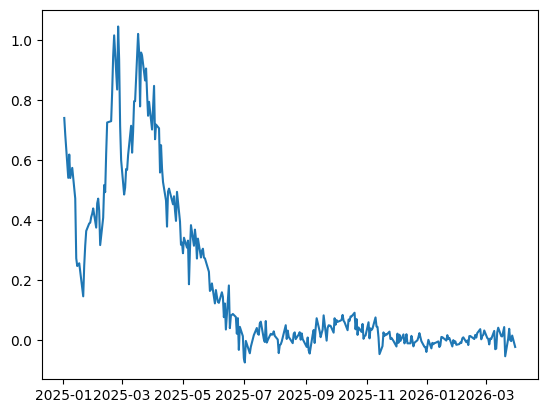

In [13]:
plt.plot(Close_price['Spread'])

In [14]:
plt.plot(spread_series)



NameError: name 'spread_series' is not defined

In [141]:
z = rolling_z_score(spread_series, window=20)
z

Date
2025-07-01         NaN
2025-07-02         NaN
2025-07-03         NaN
2025-07-07         NaN
2025-07-08         NaN
                ...   
2026-03-24    1.099550
2026-03-25   -0.352432
2026-03-26   -0.438019
2026-03-27    0.322924
2026-03-30   -1.096429
Name: (Spread, ), Length: 188, dtype: float64

In [17]:
Close_price.info

<bound method DataFrame.info of Ticker      SBH27.NYB  SBV26.NYB  SBN26.NYB   CANE    Spread
Price           Close      Close      Close  Close          
Date                                                        
2025-01-02  17.070000  16.790001  16.830000  11.67  0.740173
2025-01-03  17.139999  16.850000  16.870001  11.65  0.683837
2025-01-06  17.150000  16.840000  16.840000  11.50  0.540586
2025-01-07  17.150000  16.840000  16.850000  11.58  0.618257
2025-01-08  17.120001  16.809999  16.809999  11.48  0.539989
...               ...        ...        ...    ...       ...
2026-03-24  16.940001  16.340000  16.010000  10.66  0.037369
2026-03-25  16.730000  16.090000  15.720000  10.46 -0.000376
2026-03-26  16.959999  16.350000  16.030001  10.63 -0.003616
2026-03-27  16.940001  16.309999  15.960000  10.62  0.014865
2026-03-30  16.809999  16.160000  15.770000  10.48 -0.023180

[310 rows x 5 columns]>

In [19]:
Close_price.info

<bound method DataFrame.info of Ticker      SBH27.NYB  SBV26.NYB  SBN26.NYB   CANE    Spread
Price           Close      Close      Close  Close          
Date                                                        
2025-01-02  17.070000  16.790001  16.830000  11.67  0.740173
2025-01-03  17.139999  16.850000  16.870001  11.65  0.683837
2025-01-06  17.150000  16.840000  16.840000  11.50  0.540586
2025-01-07  17.150000  16.840000  16.850000  11.58  0.618257
2025-01-08  17.120001  16.809999  16.809999  11.48  0.539989
...               ...        ...        ...    ...       ...
2026-03-24  16.940001  16.340000  16.010000  10.66  0.037369
2026-03-25  16.730000  16.090000  15.720000  10.46 -0.000376
2026-03-26  16.959999  16.350000  16.030001  10.63 -0.003616
2026-03-27  16.940001  16.309999  15.960000  10.62  0.014865
2026-03-30  16.809999  16.160000  15.770000  10.48 -0.023180

[310 rows x 5 columns]>

In [82]:
df = Close_price.loc['2025-07-01':]
print(df.index.min())

2025-07-01 00:00:00


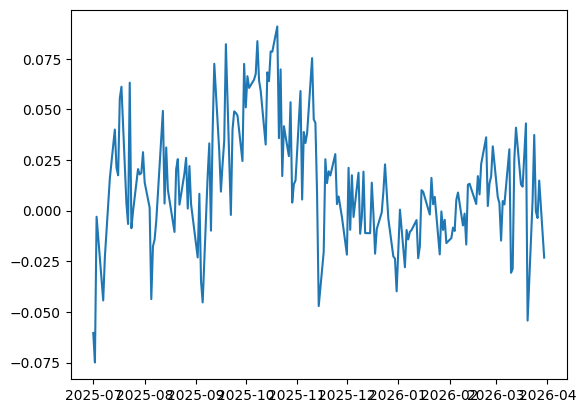

In [90]:
plt.plot(df['Spread'])

(array([154.,  52.,  12.,  21.,  20.,  14.,  11.,  12.,   6.,   8.]),
 array([-0.07493476,  0.03707873,  0.14909222,  0.26110571,  0.3731192 ,
         0.48513269,  0.59714618,  0.70915967,  0.82117316,  0.93318665,
         1.04520014]),
 <BarContainer object of 10 artists>)

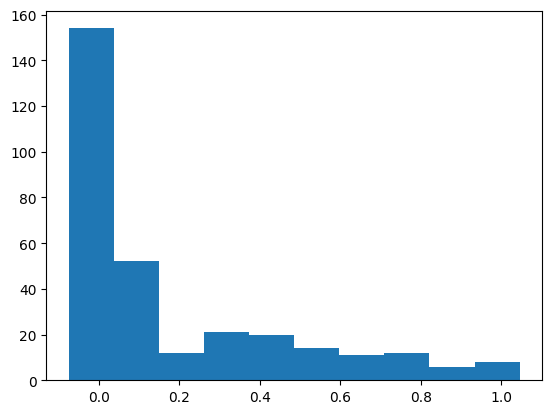

In [19]:
plt.hist(Close_price['Spread'])

In [78]:
import pandas as pd

data = {
    "Date": pd.date_range(start="2025-01-01", periods=10, freq="D"),
    "Spread": [5, 10, 15, 20, 5, -5, 5, -5, 5, 5]
}

df = pd.DataFrame(data).set_index("Date")

print(df)

            Spread
Date              
2025-01-01       5
2025-01-02      10
2025-01-03      15
2025-01-04      20
2025-01-05       5
2025-01-06      -5
2025-01-07       5
2025-01-08      -5
2025-01-09       5
2025-01-10       5


BACKTEST RESULTS
BSM                : 0.0
QPP                : 50
Win Rate (dni)     : 50.5%
Total PnL          : 2122.2578
Sharpe Ratio       : 3.00
Max Drawdown       : -188.7747
Liczba transakcji  : 188


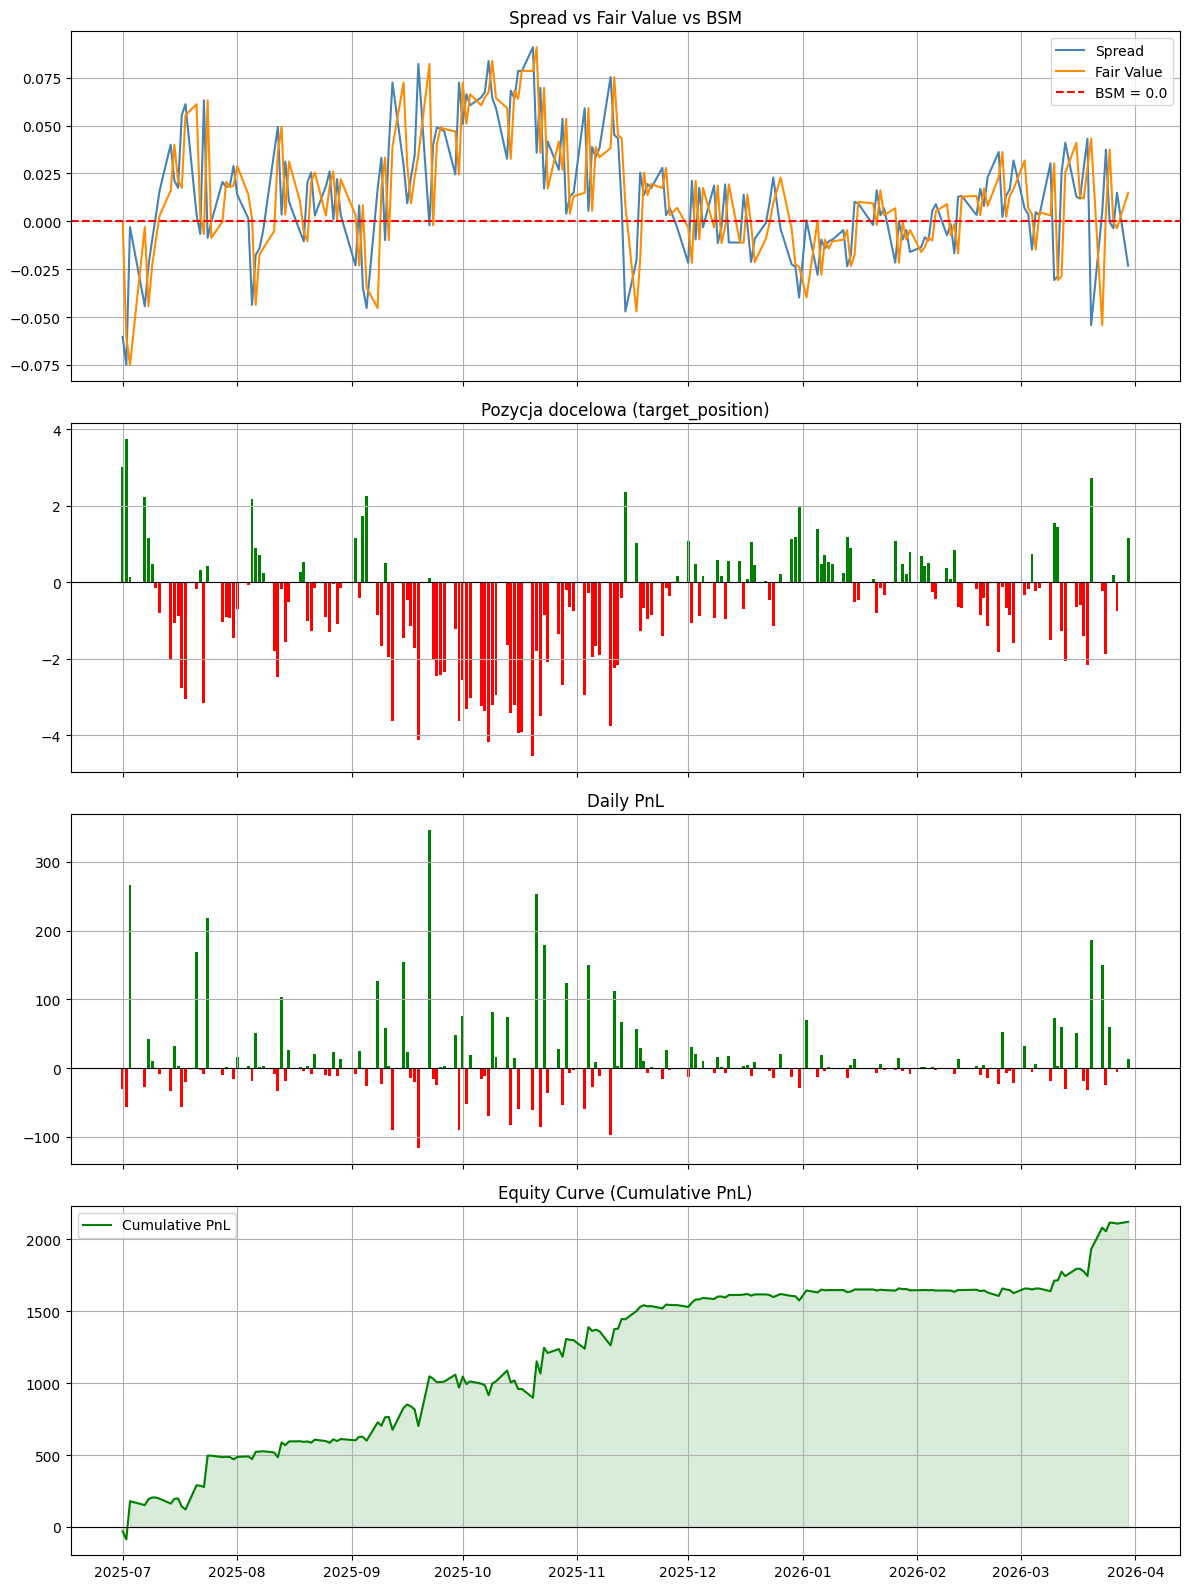

,price,bsm,fair_value_before,position_before,target_position,delta,daily_pnl,cumulative_pnl
date,,,,,,,,
2025-07-01,-0.060360,0.0,0.000000,0.000000,3.017984,3.017984,-30.179841,-30.179841
2025-07-02,-0.074935,0.0,-0.060360,3.017984,3.746738,0.728754,-56.553359,-86.733200
2025-07-03,-0.002986,0.0,-0.074935,3.746738,0.149311,-3.597427,265.946715,179.213515
2025-07-07,-0.044322,0.0,-0.002986,0.149311,2.216106,2.066795,-27.580480,151.633035
2025-07-08,-0.022895,0.0,-0.044322,2.216106,1.144769,-1.071338,42.468661,194.101696
...,...,...,...,...,...,...,...,...
2026-03-24,0.037369,0.0,0.004748,-0.237379,-1.868433,-1.631054,-24.983323,2056.682731
2026-03-25,-0.000376,0.0,0.037369,-1.868433,0.018799,1.887232,60.113814,2116.796545
2026-03-26,-0.003616,0.0,-0.000376,0.018799,0.180817,0.162018,-1.688408,2115.108136


In [109]:
daily_df, transactions= backtest_spread_strategy(
    spread=df['Spread'],
    bsm=0.0,
    qpp=50, pv = 1120,
    transaction_cost=10)

daily_df

In [98]:
transactions

,date,price,delta,position_before,position_after,fair_value_before
0,2025-07-01,-0.060360,0.301798,0.000000,0.301798,0.000000
1,2025-07-02,-0.074935,0.072875,0.301798,0.374674,-0.060360
2,2025-07-03,-0.002986,-0.359743,0.374674,0.014931,-0.074935
3,2025-07-07,-0.044322,0.206680,0.014931,0.221611,-0.002986
4,2025-07-08,-0.022895,-0.107134,0.221611,0.114477,-0.044322
...,...,...,...,...,...,...
183,2026-03-24,0.037369,-0.163105,-0.023738,-0.186843,0.004748
184,2026-03-25,-0.000376,0.188723,-0.186843,0.001880,0.037369
185,2026-03-26,-0.003616,0.016202,0.001880,0.018082,-0.000376
186,2026-03-27,0.014865,-0.092406,0.018082,-0.074325,-0.003616


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


def backtest_spread_strategy(spread, bsm, qpp, pv,transaction_cost):
    """
    Backtesting strategii inventory-based / mean-reversion, gdzie:

        FV = BSM - Position / qpp

    oraz docelowa pozycja:

        target_position = (BSM - price) * qpp

    Interpretacja:
    - price < BSM  -> long
    - price > BSM  -> short

    Parametry:
    - spread: pd.Series z cenami spreadu (datetime index)
    - bsm: stały poziom bazowy
    - qpp: quantity per point

    Zwraca:
    - daily_df
    - transactions_df
    """

    spread = spread.copy()

    daily_records = []
    transactions = []
    # z_scores = rolling_z_score(spread, z_window)
    current_position = 0.0
    prev_price = None

    for date, price in spread.items():
        # FV wynikające z pozycji na początku dnia
        fair_value_before = bsm - current_position / qpp

        # Docelowa pozycja wynikająca z ceny względem BSM
        target_position = (bsm - price) * qpp

        # Zmiana pozycji
        delta = target_position - current_position

        # Dzienny PnL liczony na pozycji z początku dnia
        if prev_price is not None and current_position !=0:
            daily_pnl = current_position * (price - prev_price)*pv
        else:
            daily_pnl = 0.0

        
        cost = abs(delta) * transaction_cost
#--------koszty transakcyjne--------
        #cost = abs(delta) * transaction_cost
        daily_pnl -= cost
        # Rejestr transakcji
        if abs(delta) > 1e-10:
            transactions.append({
                'date': date,
                'price': price,
                'delta': delta,
                'position_before': current_position,
                'position_after': target_position,
                'fair_value_before': fair_value_before
            })

        # Rejestr dzienny
        daily_records.append({
            'date': date,
            'price': price,
            'bsm': bsm,
            'fair_value_before': fair_value_before,
            'position_before': current_position,
            'target_position': target_position,
            'delta': delta,
            'daily_pnl': daily_pnl
        })

        current_position = target_position
        prev_price = price

    # --- DATAFRAME ---
    daily_df = pd.DataFrame(daily_records).set_index('date')
    daily_df['cumulative_pnl'] = daily_df['daily_pnl'].cumsum()

    transactions_df = pd.DataFrame(transactions)

    # --- STATYSTYKI ---
    total_pnl = daily_df['daily_pnl'].sum()

    pnl_std = daily_df['daily_pnl'].std()
    sharpe = (
        daily_df['daily_pnl'].mean() / pnl_std * (252 ** 0.5)
        if pnl_std > 0 else 0.0
    )

    cumpnl = daily_df['cumulative_pnl']
    max_dd = (cumpnl - cumpnl.cummax()).min()
    win_rate = (daily_df['daily_pnl'] > 0).mean() * 100

    print("=" * 50)
    print("BACKTEST RESULTS")
    print(f"BSM                : {bsm}")
    print(f"QPP                : {qpp}")
    print("=" * 50)
    print(f"Win Rate (dni)     : {win_rate:.1f}%")
    print(f"Total PnL          : {total_pnl:.4f}")
    print(f"Sharpe Ratio       : {sharpe:.2f}")
    print(f"Max Drawdown       : {max_dd:.4f}")
    print(f"Liczba transakcji  : {len(transactions_df)}")
    print("=" * 50)

    # --- WYKRESY ---
    fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

    # 1. Spread vs FV vs BSM
    axes[0].plot(daily_df.index, daily_df['price'], label='Spread', color='steelblue')
    axes[0].plot(daily_df.index, daily_df['fair_value_before'], label='Fair Value', color='darkorange')
    axes[0].axhline(bsm, color='red', linestyle='--', label=f'BSM = {bsm}')
    axes[0].set_title('Spread vs Fair Value vs BSM')
    axes[0].legend()
    axes[0].grid(True)

    # 2. Pozycja
    axes[1].bar(
        daily_df.index,
        daily_df['target_position'],
        color=[
            'green' if p > 0 else 'red' if p < 0 else 'gray'
            for p in daily_df['target_position']
        ]
    )
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].set_title('Pozycja docelowa (target_position)')
    axes[1].grid(True)

    # 3. Dzienny PnL
    axes[2].bar(
        daily_df.index,
        daily_df['daily_pnl'],
        color=['green' if p >= 0 else 'red' for p in daily_df['daily_pnl']]
    )
    axes[2].axhline(0, color='black', linewidth=0.8)
    axes[2].set_title('Daily PnL')
    axes[2].grid(True)

    # 4. Equity curve
    axes[3].plot(daily_df.index, daily_df['cumulative_pnl'], color='green', label='Cumulative PnL')
    axes[3].axhline(0, color='black', linewidth=0.8)
    axes[3].fill_between(
        daily_df.index,
        daily_df['cumulative_pnl'],
        0,
        where=(daily_df['cumulative_pnl'] >= 0),
        alpha=0.15,
        color='green'
    )
    axes[3].fill_between(
        daily_df.index,
        daily_df['cumulative_pnl'],
        0,
        where=(daily_df['cumulative_pnl'] < 0),
        alpha=0.15,
        color='red'
    )
    axes[3].set_title('Equity Curve (Cumulative PnL)')
    axes[3].legend()
    axes[3].grid(True)

    plt.tight_layout()
    plt.show()

    return daily_df, transactions_df




In [114]:
def backtest_spread_strategy_z(spread, bsm, qpp, pv,transaction_cost):
    spread = spread.copy()

    daily_records = []
    transactions = []
    z_scores = rolling_z_score(spread, z_window)

    current_position = 0.0
    prev_price = None

    for date, price in spread.items():
        z_score = z_scores.loc[date]

        # FV wynikające z pozycji na początku dnia
        fair_value_before = bsm - current_position / qpp

        # target tylko gdy sygnał jest wystarczająco mocny
        if pd.notna(z_score) and abs(z_score) > z_threshold:
            target_position = (bsm - price) * qpp
        else:
            target_position = current_position

        # Zmiana pozycji
        delta = target_position - current_position

        # Dzienny PnL liczony na pozycji z początku dnia
        if prev_price is not None and current_position != 0:
            daily_pnl = current_position * (price - prev_price) * pv
        else:
            daily_pnl = 0.0

         cost = abs(delta) * transaction_cost
#--------koszty transakcyjne--------
        #cost = abs(delta) * transaction_cost
        daily_pnl -= cost
        # Rejestr transakcji
        if abs(delta) > 1e-10:
            transactions.append({
                'date': date,
                'price': price,
                'delta': delta,
                'position_before': current_position,
                'position_after': target_position,
                'fair_value_before': fair_value_before
            })

        # Rejestr dzienny
        daily_records.append({
            'date': date,
            'price': price,
            'bsm': bsm,
            'fair_value_before': fair_value_before,
            'position_before': current_position,
            'target_position': target_position,
            'delta': delta,
            'daily_pnl': daily_pnl
        })

        current_position = target_position
        prev_price = price

    # --- DATAFRAME ---
    daily_df = pd.DataFrame(daily_records).set_index('date')
    daily_df['cumulative_pnl'] = daily_df['daily_pnl'].cumsum()

    transactions_df = pd.DataFrame(transactions)

    # --- STATYSTYKI ---
    total_pnl = daily_df['daily_pnl'].sum()

    pnl_std = daily_df['daily_pnl'].std()
    sharpe = (
        daily_df['daily_pnl'].mean() / pnl_std * (252 ** 0.5)
        if pnl_std > 0 else 0.0
    )

    cumpnl = daily_df['cumulative_pnl']
    max_dd = (cumpnl - cumpnl.cummax()).min()
    win_rate = (daily_df['daily_pnl'] > 0).mean() * 100

    print("=" * 50)
    print("BACKTEST RESULTS")
    print(f"BSM                : {bsm}")
    print(f"QPP                : {qpp}")
    print("=" * 50)
    print(f"Win Rate (dni)     : {win_rate:.1f}%")
    print(f"Total PnL          : {total_pnl:.4f}")
    print(f"Sharpe Ratio       : {sharpe:.2f}")
    print(f"Max Drawdown       : {max_dd:.4f}")
    print(f"Liczba transakcji  : {len(transactions_df)}")
    print("=" * 50)

    # --- WYKRESY ---
    fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

    # 1. Spread vs FV vs BSM
    axes[0].plot(daily_df.index, daily_df['price'], label='Spread', color='steelblue')
    axes[0].plot(daily_df.index, daily_df['fair_value_before'], label='Fair Value', color='darkorange')
    axes[0].axhline(bsm, color='red', linestyle='--', label=f'BSM = {bsm}')
    axes[0].set_title('Spread vs Fair Value vs BSM')
    axes[0].legend()
    axes[0].grid(True)

    # 2. Pozycja
    axes[1].bar(
        daily_df.index,
        daily_df['target_position'],
        color=[
            'green' if p > 0 else 'red' if p < 0 else 'gray'
            for p in daily_df['target_position']
        ]
    )
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].set_title('Pozycja docelowa (target_position)')
    axes[1].grid(True)

    # 3. Dzienny PnL
    axes[2].bar(
        daily_df.index,
        daily_df['daily_pnl'],
        color=['green' if p >= 0 else 'red' for p in daily_df['daily_pnl']]
    )
    axes[2].axhline(0, color='black', linewidth=0.8)
    axes[2].set_title('Daily PnL')
    axes[2].grid(True)

    # 4. Equity curve
    axes[3].plot(daily_df.index, daily_df['cumulative_pnl'], color='green', label='Cumulative PnL')
    axes[3].axhline(0, color='black', linewidth=0.8)
    axes[3].fill_between(
        daily_df.index,
        daily_df['cumulative_pnl'],
        0,
        where=(daily_df['cumulative_pnl'] >= 0),
        alpha=0.15,
        color='green'
    )
    axes[3].fill_between(
        daily_df.index,
        daily_df['cumulative_pnl'],
        0,
        where=(daily_df['cumulative_pnl'] < 0),
        alpha=0.15,
        color='red'
    )
    axes[3].set_title('Equity Curve (Cumulative PnL)')
    axes[3].legend()
    axes[3].grid(True)

    plt.tight_layout()
    plt.show()

    return daily_df, transactions_df




IndentationError: unindent does not match any outer indentation level (<string>, line 32)